## Download data 

In [2]:
import kagglehub

path = kagglehub.dataset_download(
    "kundanbedmutha/exam-score-prediction-dataset",
    output_dir="./data"
)

print(path)

100%|██████████| 318k/318k [00:00<00:00, 717kB/s]

Extracting files...
./data


## 1. Load data

In [19]:
from pathlib import Path
import pandas as pd

DATA_DIR = Path("data")
DATA_FILE = DATA_DIR / "Exam_Score_Prediction.csv"

df = pd.read_csv(DATA_FILE)

df

,student_id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,1,17,male,diploma,2.78,92.9,yes,7.4,poor,coaching,low,hard,58.9
1,2,23,other,bca,3.37,64.8,yes,4.6,average,online videos,medium,moderate,54.8
2,3,22,male,b.sc,7.88,76.8,yes,8.5,poor,coaching,high,moderate,90.3
3,4,20,other,diploma,0.67,48.4,yes,5.8,average,online videos,low,moderate,29.7
4,5,20,female,diploma,0.89,71.6,yes,9.8,poor,coaching,low,moderate,43.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,19997,18,other,bba,6.50,71.3,yes,5.0,good,self-study,low,easy,86.5
19996,19998,18,male,b.com,3.71,41.6,no,5.9,average,coaching,medium,moderate,60.9
19997,19999,19,other,diploma,7.88,68.2,yes,4.6,poor,group study,low,easy,64.5
19998,20000,19,male,bba,4.60,76.3,no,6.1,good,self-study,medium,moderate,79.0


## 2. Initial Data Inspection

The first step is to understand the structure, data types, and basic characteristics of the dataset before performing further analysis.

### 2.1 Dataset Structure

In [22]:
df.shape, df.columns

((20000, 13),
 Index(['student_id', 'age', 'gender', 'course', 'study_hours',
        'class_attendance', 'internet_access', 'sleep_hours', 'sleep_quality',
        'study_method', 'facility_rating', 'exam_difficulty', 'exam_score'],
       dtype='str'))

### 2.2 Data Types and Missing Values

In [23]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   student_id        20000 non-null  int64  
 1   age               20000 non-null  int64  
 2   gender            20000 non-null  str    
 3   course            20000 non-null  str    
 4   study_hours       20000 non-null  float64
 5   class_attendance  20000 non-null  float64
 6   internet_access   20000 non-null  str    
 7   sleep_hours       20000 non-null  float64
 8   sleep_quality     20000 non-null  str    
 9   study_method      20000 non-null  str    
 10  facility_rating   20000 non-null  str    
 11  exam_difficulty   20000 non-null  str    
 12  exam_score        20000 non-null  float64
dtypes: float64(4), int64(2), str(7)
memory usage: 2.0 MB


### 2.3 Numerical Statistics

In [25]:
df.describe()

,student_id,age,study_hours,class_attendance,sleep_hours,exam_score
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000,20000.000000
mean,10000.504600,20.473300,4.007604,70.017365,7.00856,62.513225
std,5773.654959,2.284458,2.308313,17.282262,1.73209,18.908491
min,1.000000,17.000000,0.080000,40.600000,4.10000,19.599000
25%,5000.750000,18.000000,2.000000,55.100000,5.50000,48.800000
50%,10000.500000,20.000000,4.040000,69.900000,7.00000,62.600000
75%,15000.250000,22.000000,6.000000,85.000000,8.50000,76.300000
max,20001.000000,24.000000,7.910000,99.400000,9.90000,100.000000


### 2.4 Unique Values

In [ ]:
for column in df.select_dtypes(include="str").columns:
    print(column, ":", df[column].unique())

gender : <StringArray>
['male', 'other', 'female']
Length: 3, dtype: str
course : <StringArray>
['diploma', 'bca', 'b.sc', 'b.tech', 'bba', 'ba', 'b.com']
Length: 7, dtype: str
internet_access : <StringArray>
['yes', 'no']
Length: 2, dtype: str
sleep_quality : <StringArray>
['poor', 'average', 'good']
Length: 3, dtype: str
study_method : <StringArray>
['coaching', 'online videos', 'mixed', 'self-study', 'group study']
Length: 5, dtype: str
facility_rating : <StringArray>
['low', 'medium', 'high']
Length: 3, dtype: str
exam_difficulty : <StringArray>
['hard', 'moderate', 'easy']
Length: 3, dtype: str


## 3. Exploratory Data Analysis

### 3.1 Study Hours vs Exam Score
The scatter plot is used to investigate whether there is a relationship between the number of hours students spend studying and their exam scores.

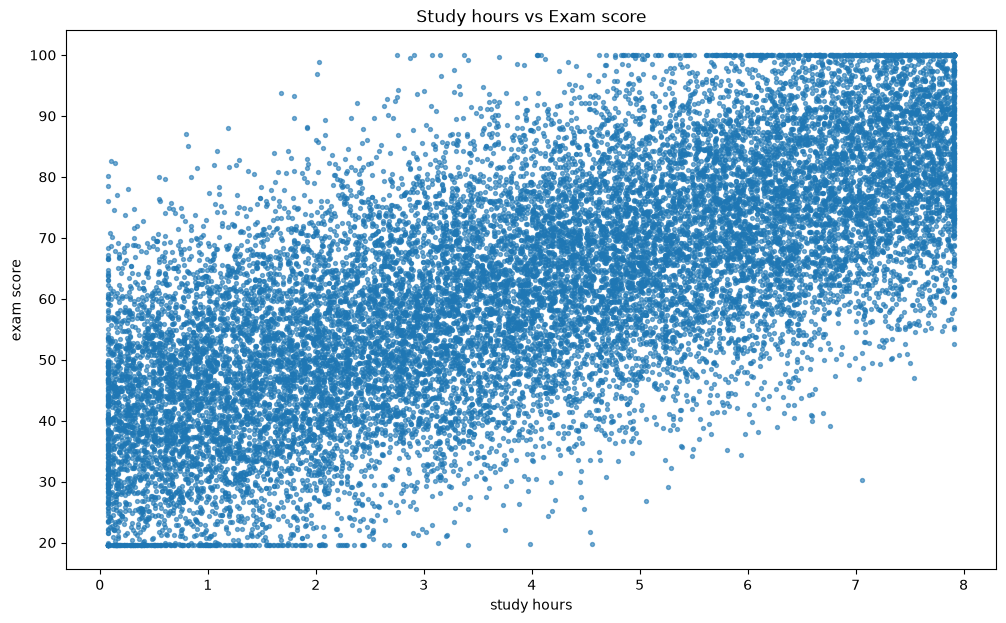

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

x = np.array(df['study_hours'])
y = np.array(df['exam_score'])

plt.figure(figsize=(12, 7))
plt.scatter(x, y, s=8, alpha=0.6)

plt.xlabel("study hours")
plt.ylabel("exam score")

plt.title("Study hours vs Exam score")

plt.show()

### Observation
study_hours shows a relatively strong positive relationship with <b>exam_score</b>. This is also supported by the Pearson correlation coefficient of approximately 0.718.

### 3.2 Class Attendance vs Exam Score
The scatter plot suggests a positive relationship between class attendance and exam score. Students with higher attendance generally tend to achieve higher scores.

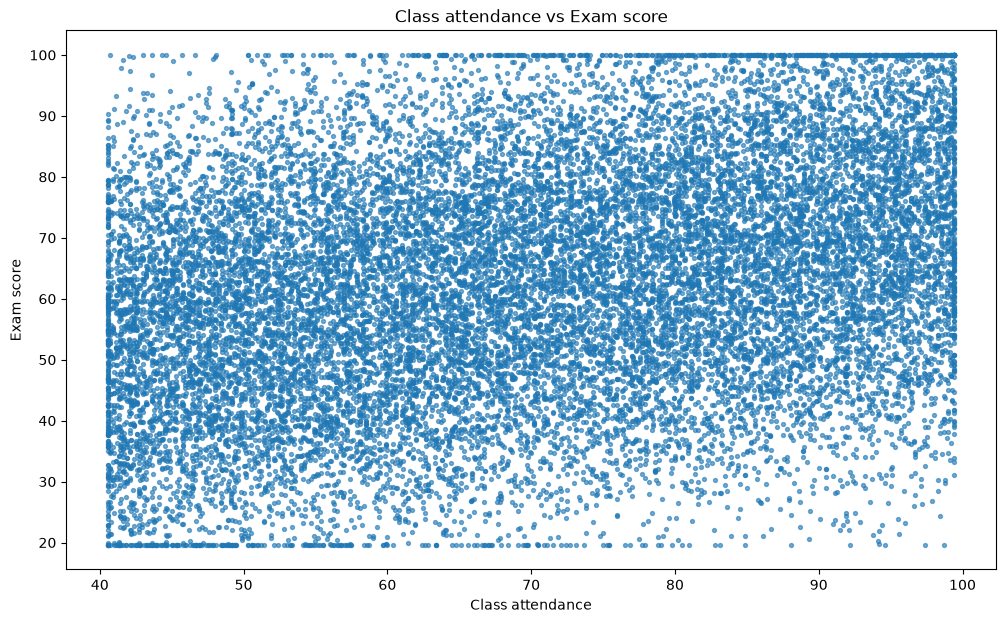

In [90]:
x = np.array(df['class_attendance'])
y = np.array(df['exam_score'])

plt.figure(figsize=(12,7))
plt.scatter(x, y, s=8, alpha=0.6)

plt.title("Class attendance vs Exam score")
plt.xlabel("Class attendance")
plt.ylabel("Exam score")

plt.show()

### Observation
The scatter plot suggests a positive relationship between class attendance and exam score. Students with higher attendance generally tend to achieve higher scores.

### 3.3 Sleep Hours vs Exam Score

The relationship between sleep_hours and exam_score appears to be weakly positive. Although students with more sleep tend to have slightly higher scores, the relationship is much weaker than for study_hours and class_attendance.

The Pearson correlation coefficient is approximately 0.133.

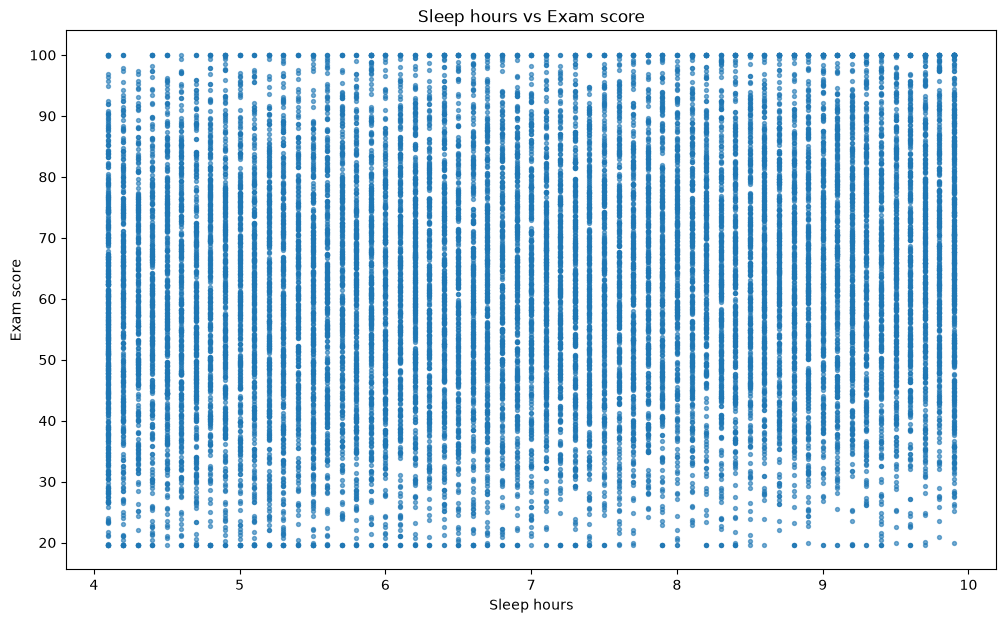

In [89]:
x = np.array(df['sleep_hours'])
y = np.array(df['exam_score'])

plt.figure(figsize=(12,7))
plt.scatter(x, y, s=8, alpha=0.6)

plt.title("Sleep hours vs Exam score")
plt.xlabel("Sleep hours")
plt.ylabel("Exam score")

plt.show()

### 3.4 Correlation Analysis

Pearson correlation was calculated for the numerical variables to measure the strength and direction of their linear relationships.

Among the numerical features, study_hours has the strongest positive correlation with exam_score (0.718), followed by class_attendance (0.309) and sleep_hours (0.133).

age has almost no linear correlation with exam_score (0.007).

In [52]:
df.corr(numeric_only=True)

,student_id,age,study_hours,class_attendance,sleep_hours,exam_score
student_id,1.000000,-0.002574,0.002116,0.001128,-0.000560,0.003269
age,-0.002574,1.000000,0.002955,0.008449,-0.000385,0.006522
study_hours,0.002116,0.002955,1.000000,-0.001645,-0.004533,0.717788
class_attendance,0.001128,0.008449,-0.001645,1.000000,0.007187,0.308850
sleep_hours,-0.000560,-0.000385,-0.004533,0.007187,1.000000,0.133222
exam_score,0.003269,0.006522,0.717788,0.308850,0.133222,1.000000


### 3.5 Categorical Features vs Exam Score

Boxplots are used to compare the distribution of exam scores across different categories. This allows us to identify whether students belonging to different groups tend to achieve different exam results.

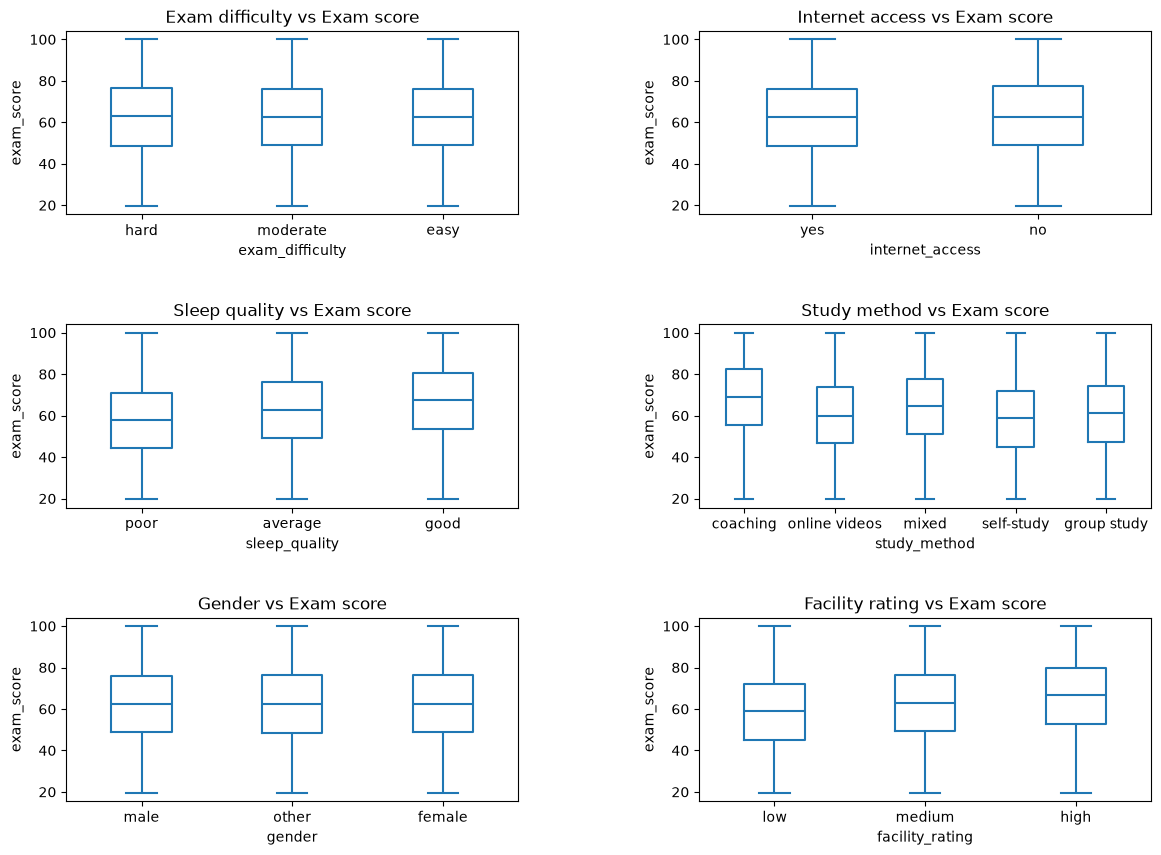

In [87]:
import seaborn as sns

plt.subplots(3, 2, figsize=(14, 10))

plt.subplot(3, 2, 1)
sns.boxplot(data=df, x="exam_difficulty", y="exam_score", fill=False, gap=.5)
plt.title("Exam difficulty vs Exam score")

plt.subplot(3, 2, 2)
sns.boxplot(data=df, x="internet_access", y="exam_score", fill=False, gap=.5)
plt.title("Internet access vs Exam score")

plt.subplot(3, 2, 3)
sns.boxplot(data=df, x="sleep_quality", y="exam_score", fill=False, gap=.5)
plt.title("Sleep quality vs Exam score")

plt.subplot(3, 2, 4)
sns.boxplot(data=df, x="study_method", y="exam_score", fill=False, gap=.5)
plt.title("Study method vs Exam score")

plt.subplot(3, 2, 5)
sns.boxplot(data=df, x="gender", y="exam_score", fill=False, gap=.5)
plt.title("Gender vs Exam score")

plt.subplot(3, 2, 6)
sns.boxplot(data=df, x="facility_rating", y="exam_score", fill=False, gap=.5)
plt.title("Facility rating vs Exam score")

plt.subplots_adjust(wspace=0.4)
plt.subplots_adjust(hspace=0.6)
plt.show()

### Observations

The boxplots show noticeable differences in exam scores across facility_rating, sleep_quality, and study_method.

Higher facility ratings are associated with higher observed exam scores. sleep_quality also shows differences between categories, with better sleep quality generally associated with higher scores.

Exam scores also vary across study methods, with the coaching group showing the highest observed scores.

These observations indicate that these categorical features may contain useful information for predicting exam scores. However, the observed differences do not prove causation.

### 3.6 Exam Score Distribution

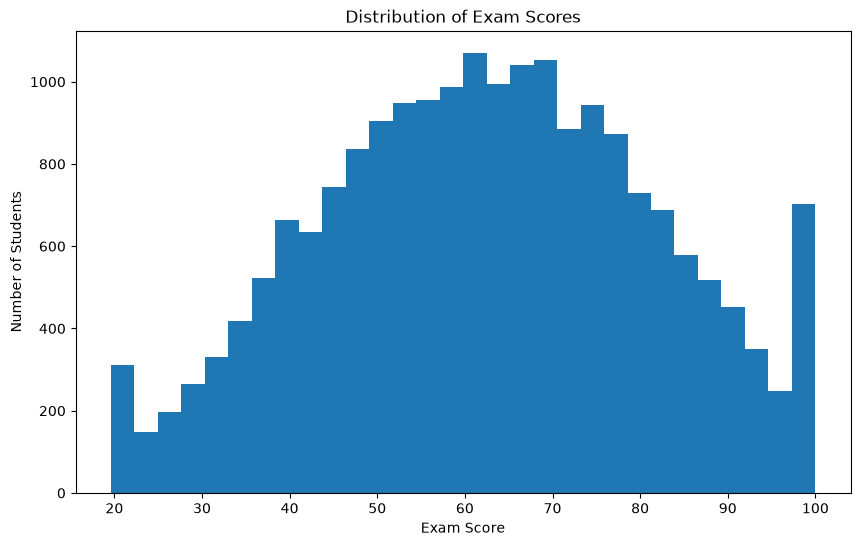

In [88]:
plt.figure(figsize=(10, 6))

plt.hist(df["exam_score"], bins=30)

plt.xlabel("Exam Score")
plt.ylabel("Number of Students")
plt.title("Distribution of Exam Scores")

plt.show()

### Observation

Most exam scores are concentrated between approximately 50 and 80 points. There are also noticeable concentrations near the lower and upper ends of the scale, particularly around 20 and 100.

The target variable therefore does not appear to be uniformly distributed across the full score range.

### 3.7 EDA Summary

The exploratory analysis revealed several potentially useful relationships with exam_score.

- study_hours has the strongest positive linear correlation with exam_score (approximately 0.718).
- class_attendance has a moderate positive correlation with exam score (approximately 0.309).
- sleep_hours has a weak positive correlation with exam score (approximately 0.133).
- Differences in exam scores were observed across sleep_quality, study_method, and facility_rating.
- The coaching study method showed the highest observed exam scores among the study methods.
- student_id does not provide meaningful information for prediction and should not be used as a feature.
- Most exam scores are concentrated between approximately 50 and 80, with additional concentrations near 20 and 100.

These observations will guide the next stage of the project: preparing the data for machine learning and building a regression model.

## 4. Create Regression Model 

### 4.1 Split the data into train and test datasets

In [96]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["student_id", "exam_score"])
y = df["exam_score"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train.shape, X_test.shape, y_train.shape, y_test.shape


((16000, 11), (4000, 11), (16000,), (4000,))

### 4.2 Data preprocessing

In [101]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

numeric_features = X_train.select_dtypes(include="number").columns
categorical_features = X_train.select_dtypes(include="str").columns

preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(X_train_preprocessed.shape, X_test_processed.shape)

(16000, 30) (4000, 30)


### 4.3 Regression Model

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train_preprocessed, y_train)

y_pred = model.predict(X_test_processed)

array([ 36.79712092,  79.95720905,  54.43249825, 102.14749404,
        80.63235549,  39.30385838,  55.40588587,  75.82269437,
        67.42144057,  29.05009255])

## 4.4 Model prediction vs Real exam scores

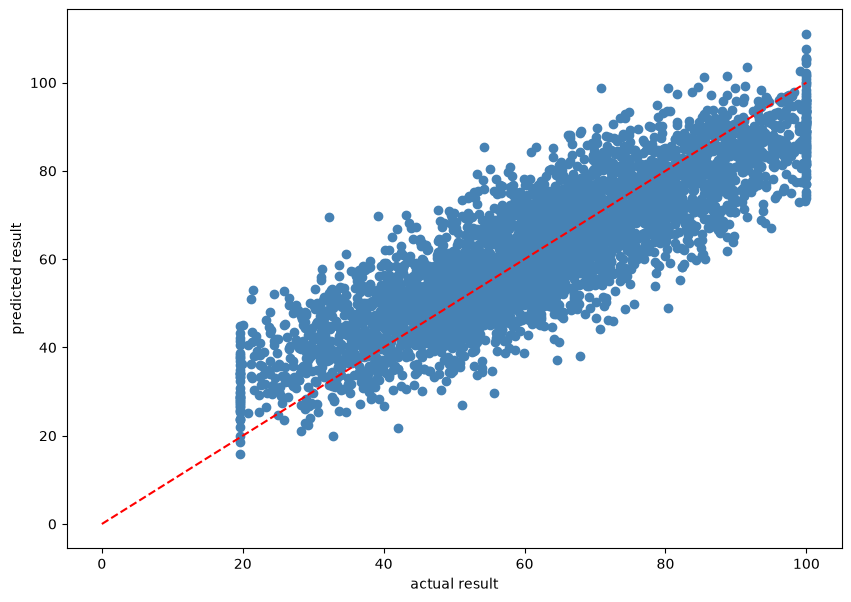

In [129]:
comparison = pd.DataFrame({
    "actual": y_test,
    "predicted": y_pred,
})

plt.figure(figsize=(10, 7))
plt.scatter(comparison["actual"], comparison["predicted"], color="steelblue")

plt.plot(
    [0, 100],
    [0, 100],
    color="red",
    linestyle="--"
)

plt.xlabel("actual result")
plt.ylabel("predicted result")

plt.show()

In [118]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

rmse = mean_squared_error(y_test, y_pred) ** 0.5
mea = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Root mean squared error: {rmse:.02f}\nMean absolute error: {mea:.02f}\nR^2: {r2:.02f}")

Root mean squared error: 9.77
Mean absolute error: 7.86
R^2: 0.73


### Observation

The first Linear Regression model achieved the following results on the test set:

MAE: 7.86
RMSE: 9.77
R²: 0.73

The model's predictions differ from the actual exam scores by approximately 7.86 points on average. The R² score of 0.73 indicates that the model explains approximately 73% of the variance in exam scores.

## 5. Project Summary

The goal of this project is to predict students' exam scores using demographic, academic, and lifestyle features.

During EDA, study_hours showed the strongest correlation with exam_score, while class_attendance and sleep_hours showed weaker positive relationships. Differences were also observed across sleep_quality, study_method, and facility_rating.

The data was split into training and test sets. Categorical features were encoded using OneHotEncoder, resulting in 30 features after preprocessing.

The baseline LinearRegression model achieved:

MAE: 7.86
RMSE: 9.77
R²: 0.73